<a href="https://colab.research.google.com/github/HowardHNguyen/Data_Science_for_Marketing_Solutions/blob/main/Why_People_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%matplotlib inline

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

In [ ]:
import statsmodels.api as sm

# 0. Data

Source: https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/_Python/Machine-Learning-and-Generative-AI-for-Marketing/ch.3/churn-data.csv")

In [ ]:
sorted(df.columns)

['Age',
 'Balance',
 'CreditScore',
 'CustomerId',
 'EstimatedSalary',
 'Exited',
 'Gender',
 'Geography',
 'HasCrCard',
 'IsActiveMember',
 'NumOfProducts',
 'RowNumber',
 'Surname',
 'Tenure']

In [ ]:
df.shape

(10000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df["MultipleProduct"] = df["NumOfProducts"].apply(lambda x: 1 if x > 1 else 0)

In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,MultipleProduct
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.491600
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.499954
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000


# 1. Effect Estimation

In [ ]:
!pip install dowhy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.4/398.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 58.9 MB/s eta 0:00:00
  Attempting uninstall: cython
    Found existing installation: Cython 3.0.12
    Uninstalling Cython-3.0.12:
      Successfully uninstalled Cython-3.0.12


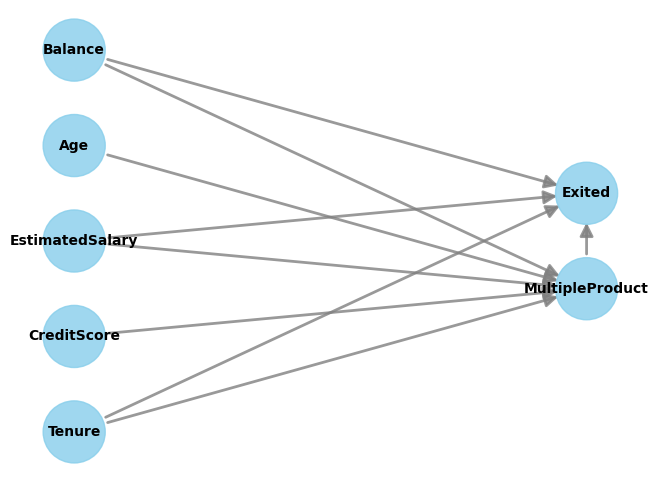

In [ ]:
from dowhy import CausalModel
model = CausalModel(
    data=df,
    treatment="MultipleProduct",
    outcome="Exited",
    common_causes=["Balance", "EstimatedSalary", "Tenure"],
    instruments=["Age", "CreditScore"]
)
model.view_model()

In [ ]:
estimands = model.identify_effect()
print(estimands)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                   
──────────────────(E[Exited|Tenure,EstimatedSalary,Balance])
d[MultipleProduct]                                          
Estimand assumption 1, Unconfoundedness: If U→{MultipleProduct} and U→Exited then P(Exited|MultipleProduct,Tenure,EstimatedSalary,Balance,U) = P(Exited|MultipleProduct,Tenure,EstimatedSalary,Balance)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                    -1⎤
 ⎢         d                  ⎛         d                            ⎞  ⎥
E⎢───────────────────(Exited)⋅⎜───────────────────([MultipleProduct])⎟  ⎥
 ⎣d[Age  CreditScore]         ⎝d[Age  CreditScore]                   ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→Exited then ¬(U →→{Age,CreditScore})
Estimand assumption 2, Exclusion: If we remove {Age,CreditScore}→{MultipleP

In [ ]:
#Causal Effect Estimation
estimate = model.estimate_effect(
    estimands,
    method_name = "backdoor.propensity_score_weighting"
)
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                   
──────────────────(E[Exited|Tenure,EstimatedSalary,Balance])
d[MultipleProduct]                                          
Estimand assumption 1, Unconfoundedness: If U→{MultipleProduct} and U→Exited then P(Exited|MultipleProduct,Tenure,EstimatedSalary,Balance,U) = P(Exited|MultipleProduct,Tenure,EstimatedSalary,Balance)

## Realized estimand
b: Exited~MultipleProduct+Tenure+EstimatedSalary+Balance
Target units: ate

## Estimate
Mean value: -0.13773249533580434



In [ ]:
refute_results = model.refute_estimate(
    estimands,
    estimate,
    "random_common_cause"
)
print(refute_results)

Refute: Add a random common cause
Estimated effect:-0.13773249533580434
New effect:-0.13773249533580434
p value:1.0



In [ ]:
refute_results = model.refute_estimate(
    estimands,
    estimate,
    "data_subset_refuter"
)
print(refute_results)

Refute: Use a subset of data
Estimated effect:-0.13773249533580434
New effect:-0.13785850612566608
p value:0.96



In [ ]:
refute_results = model.refute_estimate(
    estimands,
    estimate,
    "placebo_treatment_refuter"
)
print(refute_results)

Refute: Use a Placebo Treatment
Estimated effect:-0.13773249533580434
New effect:0.03624716231885812
p value:0.0



# 2. Graphical Causal Model

In [ ]:
import networkx as nx

causal_graph = nx.DiGraph([
    ('CreditScore', 'MultipleProduct'),
    ('Age', 'MultipleProduct'),
    ('MultipleProduct', 'Exited'),
    ('Balance', 'MultipleProduct'),
    ('EstimatedSalary', 'MultipleProduct'),
    ('Tenure', 'MultipleProduct'),
    ('Balance', 'Exited'),
    ('EstimatedSalary', 'Exited'),
    ('Tenure', 'Exited'),
])

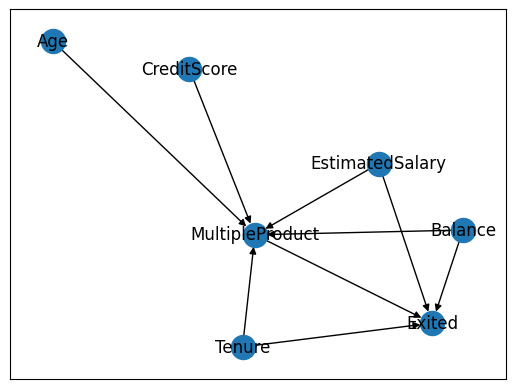

In [ ]:
nx.draw_networkx(causal_graph, arrows=True)

In [ ]:
from dowhy import gcm

# Create the structural causal model object
scm = gcm.StructuralCausalModel(causal_graph)

# Automatically assign generative models to each node based on the given data
gcm.auto.assign_causal_mechanisms(scm, df)

In [ ]:
gcm.fit(scm, df)

Fitting causal mechanism of node Tenure: 100%|██████████| 7/7 [00:00<00:00, 186.67it/s]


In [ ]:
arrow_strengths = gcm.arrow_strength(scm, target_node='Exited')
arrow_strengths

{('Balance', 'Exited'): np.float64(0.002822764227642275),
 ('EstimatedSalary', 'Exited'): np.float64(0.005205700000000004),
 ('MultipleProduct', 'Exited'): np.float64(0.012484785714285709),
 ('Tenure', 'Exited'): np.float64(0.005881224299065418)}

- **Interpretation:**
 - Balance → Exited (0.0028): The feature "Balance" has a very small positive influence on predicting "Exited." Its low value suggests it’s not a strong predictor.
 - EstimatedSalary → Exited (0.0052): "EstimatedSalary" has a slightly larger positive influence on "Exited" compared to "Balance," but still relatively weak.
 - MultipleProduct → Exited (0.0125): This has the highest value, indicating that the hidden layer "MultipleProduct" (likely capturing interactions between input features) has the strongest influence on predicting "Exited." This makes sense since "MultipleProduct" is a processed layer in the neural network, combining information from all input features.
 - Tenure → Exited (0.0059): "Tenure" has a moderate positive influence on "Exited," stronger than "Balance" and "EstimatedSalary" but weaker than "MultipleProduct."
- Context with the Neural Network Plot: In the neural network architecture you shared, "MultipleProduct" is the hidden layer that processes all input features ("Balance," "Age," "EstimatedSalary," "CreditScore," "Tenure") before passing information to the output layer ("Exited"). The higher weight for "MultipleProduct → Exited" reflects its role in aggregating and transforming the input features, making it more directly impactful on the final prediction compared to individual input features.
- Conclusion: The "MultipleProduct" hidden layer is the most influential in predicting "Exited," which aligns with its role in the network. Individual features like "Balance," "EstimatedSalary," and "Tenure" have smaller, more direct influences, with "Tenure" being the most impactful among them. Note that "Age" and "CreditScore" are not listed here, suggesting they might have even weaker or negligible influences in this specific analysis.

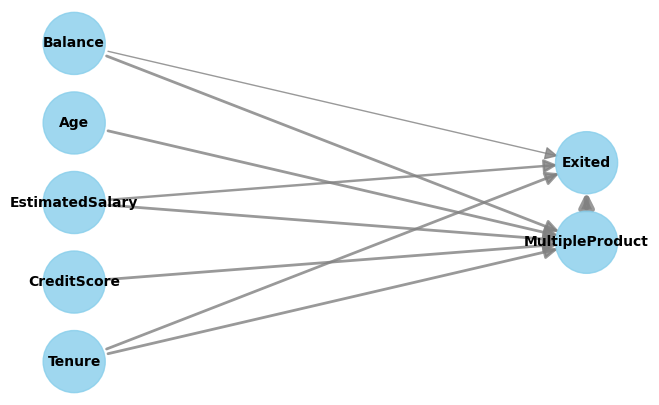

In [ ]:
total = sum(arrow_strengths.values())
arrow_strengths_perc = {key: val/total*100 for key, val in arrow_strengths.items()}

gcm.util.plot(
    causal_graph,
    causal_strengths=arrow_strengths_perc,
    figure_size=[8, 5]
)

In [ ]:
influence = gcm.intrinsic_causal_influence(scm, target_node='Exited', num_samples_randomization=100)

Evaluating set functions...: 100%|██████████| 78/78 [00:37<00:00,  2.09it/s]


In [ ]:
total = sum([val for key, val in influence.items() if key != "Exited"])
influence_perc = {key: val/total*100 for key, val in influence.items() if key != "Exited"}
influence_perc

{'CreditScore': np.float64(-0.058765961439909475),
 'Age': np.float64(-0.21593744952403582),
 'Balance': np.float64(37.4989781282676),
 'EstimatedSalary': np.float64(10.0898401035786),
 'Tenure': np.float64(11.340344750544777),
 'MultipleProduct': np.float64(41.34554042857297)}

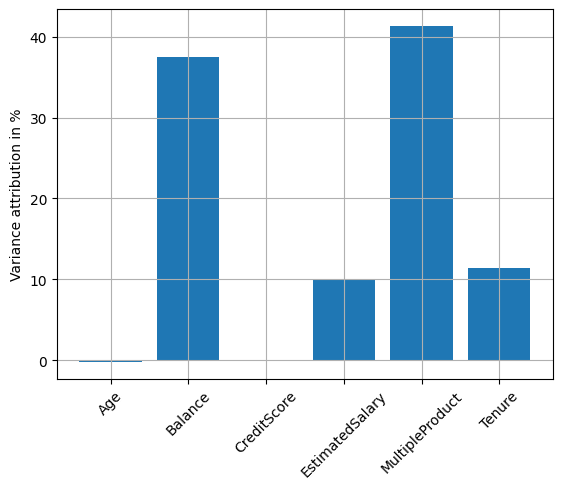

In [ ]:
xlabels = sorted(influence_perc.keys())
yvals = [influence_perc[x] for x in xlabels]
plt.bar(xlabels, yvals)
plt.xticks(rotation=45)
plt.grid()
plt.ylabel("Variance attribution in %")
plt.show()

In [ ]:
attributions = gcm.attribute_anomalies(
    scm,
    target_node='Exited',
    anomaly_samples=df.loc[df["Exited"] == 1].iloc[1:2]
)

Evaluating set functions...: 100%|██████████| 90/90 [00:21<00:00,  4.26it/s]


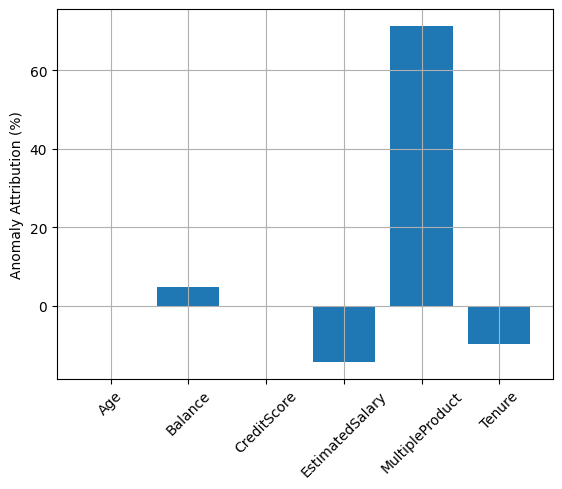

In [ ]:
total = sum([abs(val[0]) for key, val in attributions.items() if key != "Exited"])
attributions_perc = {key: val[0]/total*100 for key, val in attributions.items() if key != "Exited"}

xlabels = sorted(attributions_perc.keys())
yvals = [attributions_perc[x] for x in xlabels]
plt.bar(xlabels, yvals)
plt.xticks(rotation=45)
plt.grid()
plt.ylabel("Anomaly Attribution (%)")
plt.show()

The bar chart displays the "Anomaly Attribution (%)" for different features in the context of your neural network model, likely indicating how much each feature contributes to detecting anomalies in the data (e.g., predicting "Exited"). Here's the interpretation:

- Features and Their Contributions:
 - MultipleProduct: This feature has the highest anomaly attribution, around 60%. This aligns with its role as the hidden layer in your neural network (as seen in the earlier plot), which processes all input features and has the strongest influence on the "Exited" prediction (as confirmed by the weights you provided, where it had a value of 0.0125).
 - Age, Balance, CreditScore, EstimatedSalary, Tenure: These features have negative anomaly attribution values, ranging roughly between -5% and -10%. A negative attribution suggests that these features are not strongly associated with anomalies in the data. They might even be reducing the likelihood of detecting an anomaly (e.g., a customer exiting).
- Context with Previous Data:
 - The high attribution of "MultipleProduct" is consistent with the weights you shared earlier, where it had the strongest connection to "Exited" (0.0125), compared to the other features like "Balance" (0.0028), "EstimatedSalary" (0.0052), and "Tenure" (0.0059).
 - The negative attribution for "Balance," "EstimatedSalary," and "Tenure" aligns with their relatively low weights in the dictionary, indicating they have a weaker direct influence on the "Exited" prediction.
 - "Age" and "CreditScore" were not listed in the weights dictionary, and their negative attribution here suggests they have minimal or counterproductive roles in anomaly detection for this model.
- Conclusion:
 - The hidden layer "MultipleProduct" is the primary driver for detecting anomalies (e.g., predicting "Exited"), contributing significantly with a 60% attribution.
 - The input features ("Age," "Balance," "CreditScore," "EstimatedSalary," "Tenure") have small, negative contributions, suggesting they are less useful for anomaly detection in this context. This makes sense because the neural network likely captures most of the predictive power through the "MultipleProduct" layer, which combines and transforms these input features into a more meaningful representation for the task.

In [ ]:
df.loc[df["Exited"] == 1].iloc[1][list(attributions_perc.keys())]

,2
CreditScore,502
Age,42
Balance,159660.8
EstimatedSalary,113931.57
Tenure,8
MultipleProduct,1
